**Boston — blank run**

Tabular data in, a price out. Same rhythm: load the sheet, wire up X and y, clean and split, scale, drop a small dense net on it, train, then read the numbers and draw the story.

In [17]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
# Load dataset
data = pd.read_csv('HousingData.csv')

data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
# Preprocess & split
X = data.drop('MEDV', axis=1)
y = data['MEDV']

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
# Model & compile
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(metrics=['mae'], loss='mean_absolute_error', optimizer='adam')

/Users/froncort.ai/Desktop/LP_5/lp5/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Train & predict

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.6151 - mae: 22.6151 - val_loss: 21.0901 - val_mae: 21.0901
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.1599 - mae: 21.1599 - val_loss: 19.3227 - val_mae: 19.3227
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.8479 - mae: 18.8479 - val_loss: 16.3398 - val_mae: 16.3398
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.3034 - mae: 15.3034 - val_loss: 12.3572 - val_mae: 12.3572
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.9184 - mae: 10.9184 - val_loss: 7.5878 - val_mae: 7.5878
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.7147 - mae: 7.7147 - val_loss: 5.5518 - val_mae: 5.5518
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1858 - mae: 6.1858 - val_loss: 4.7454 - val_mae: 4.7454
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.0063 - mae: 5.0063 - val_loss: 4.1536 - val_mae: 4.1536
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [22]:
# Evaluate & plot
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 



Model Performance
-------------------
MSE      : 13.39
RMSE     : 3.66
R2 Score : 0.8174


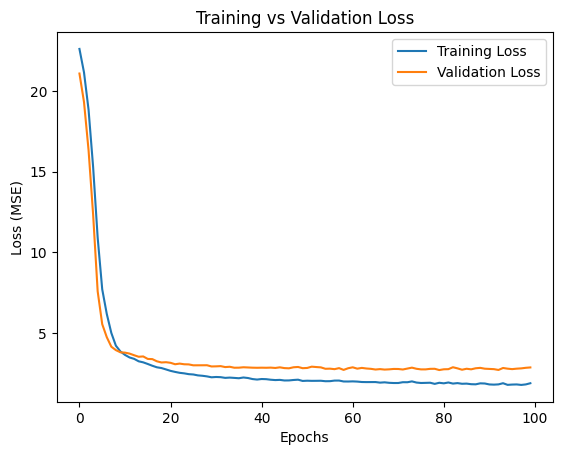

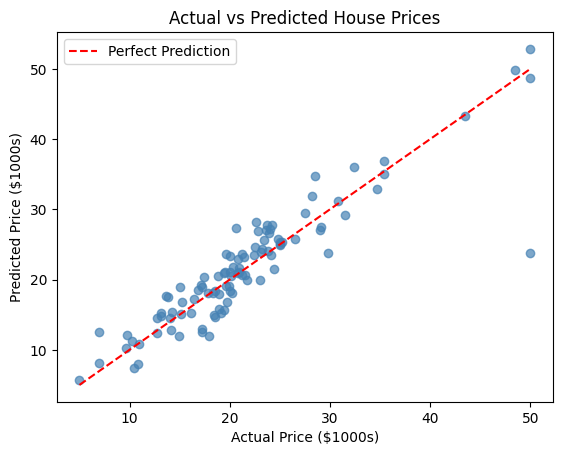

In [ ]:
# ── Step 6: Evaluate & Visualise ─────────────────────────────────────────────
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

# R2 close to 1.0 = good. Negative = worse than predicting the mean.
print("\nModel Performance")
print("-------------------")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

# Loss curve — training and validation should both go down together
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Scatter: points close to the red diagonal = accurate predictions
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()